# Road Surface Analysis & Pothole Detection v2
### Gyroscope + Accelerometer anomaly detection with classification
**Key improvements:**
- Traffic/stationary filtering (speed-based)
- Spatial clustering (merges nearby readings)
- Classification: Pothole | Speed Breaker | Driver Behavior
- Metrics: Roughness Index, Pothole Size, Severity
- Leaflet interactive map with color-coded markers

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import folium
from folium.plugins import MarkerCluster
import warnings, os, gc, logging
from sklearn.cluster import DBSCAN

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load All Sensor Data (Gyroscope + Accelerometer + Location)

In [18]:
DATA_ROOT = os.path.join('..', '')  # data folders are in parent directory
folders = ['A', 'B', 'C', 'D', 'E', 'F']

def load_route(folder):
    """Load gyroscope, accelerometer, and location data."""
    base = os.path.join(DATA_ROOT, folder)
    gyro = pd.read_csv(os.path.join(base, 'Gyroscope.csv'),
                       dtype={'x':'float32','y':'float32','z':'float32','seconds_elapsed':'float32'})
    accel = pd.read_csv(os.path.join(base, 'Accelerometer.csv'),
                        dtype={'x':'float32','y':'float32','z':'float32','seconds_elapsed':'float32'})
    total = pd.read_csv(os.path.join(base, 'TotalAcceleration.csv'),
                        dtype={'x':'float32','y':'float32','z':'float32','seconds_elapsed':'float32'})
    loc = pd.read_csv(os.path.join(base, 'Location.csv'),
                      dtype={'latitude':'float64','longitude':'float64',
                             'altitude':'float32','speed':'float32','seconds_elapsed':'float32'})
    return gyro, accel, total, loc

all_data = {}
for f in folders:
    gyro, accel, total, loc = load_route(f)
    all_data[f] = {'gyro': gyro, 'accel': accel, 'total': total, 'location': loc}
    print(f"Route {f}: gyro={len(gyro):,}  accel={len(accel):,}  loc={len(loc):,}")

print("\nAll data loaded.")

Route A: gyro=13,255  accel=13,249  loc=138
Route B: gyro=31,531  accel=31,524  loc=327
Route C: gyro=12,108  accel=12,108  loc=126
Route D: gyro=34,022  accel=34,020  loc=353
Route E: gyro=38,639  accel=38,632  loc=400
Route F: gyro=19,898  accel=19,897  loc=206

All data loaded.


## 1b. Pre-compute Speed Context for Every Sensor Timestamp
Interpolate GPS speed onto sensor timestamps → detect **car start/stop phases** and **speed transitions**.
This is critical for filtering false positives.

In [19]:
def compute_speed_context(loc_df, sensor_seconds):
    """
    Interpolate speed from GPS onto every sensor timestamp.
    Also compute:
      - gps_accel: rate of speed change (m/s²) from GPS
      - is_start_phase: car transitioning from stopped to moving
      - is_stop_phase: car transitioning from moving to stopped
    """
    loc_t = loc_df['seconds_elapsed'].values.astype('float64')
    loc_speed = loc_df['speed'].values.astype('float64')
    sensor_t = sensor_seconds.values.astype('float64')
    
    # Interpolate speed onto sensor timestamps
    interp_speed = np.interp(sensor_t, loc_t, loc_speed)
    
    # Compute GPS-based acceleration (smoothed speed derivative)
    # Use location data directly since it's ~1Hz
    gps_accel_raw = np.gradient(loc_speed, loc_t)
    interp_accel = np.interp(sensor_t, loc_t, gps_accel_raw)
    
    # Detect transitions: rolling window speed history
    # "start phase" = speed was < 1 m/s in last 3 seconds
    # "stop phase" = speed drops to < 1 m/s within next 3 seconds
    is_start = np.zeros(len(sensor_t), dtype=bool)
    is_stop = np.zeros(len(sensor_t), dtype=bool)
    
    for i, t in enumerate(sensor_t):
        # Look back 3 seconds
        back_mask = (loc_t >= t - 3.0) & (loc_t <= t)
        if back_mask.sum() > 0:
            min_speed_back = loc_speed[back_mask].min()
            if min_speed_back < 1.0 and interp_speed[i] > 1.0:
                is_start[i] = True
        
        # Look forward 3 seconds
        fwd_mask = (loc_t >= t) & (loc_t <= t + 3.0)
        if fwd_mask.sum() > 0:
            min_speed_fwd = loc_speed[fwd_mask].min()
            if min_speed_fwd < 1.0 and interp_speed[i] > 1.0:
                is_stop[i] = True
    
    return pd.DataFrame({
        'seconds_elapsed': sensor_t,
        'speed': interp_speed.astype('float32'),
        'gps_accel': interp_accel.astype('float32'),
        'is_start_phase': is_start,
        'is_stop_phase': is_stop
    })

# Compute for all routes
for folder in folders:
    d = all_data[folder]
    ctx = compute_speed_context(d['location'], d['gyro']['seconds_elapsed'])
    all_data[folder]['speed_ctx'] = ctx
    n_start = ctx['is_start_phase'].sum()
    n_stop = ctx['is_stop_phase'].sum()
    print(f"Route {folder}: {n_start} start-phase points, "
          f"{n_stop} stop-phase points, "
          f"speed range: {ctx['speed'].min():.1f}-{ctx['speed'].max():.1f} m/s")

print("\nSpeed context computed for all routes.")

Route A: 237 start-phase points, 0 stop-phase points, speed range: 0.0-11.3 m/s
Route B: 1683 start-phase points, 1954 stop-phase points, speed range: 0.0-7.8 m/s
Route C: 0 start-phase points, 0 stop-phase points, speed range: 1.5-17.9 m/s
Route D: 1000 start-phase points, 805 stop-phase points, speed range: 0.0-12.3 m/s
Route E: 496 start-phase points, 197 stop-phase points, speed range: 0.0-12.5 m/s
Route F: 1347 start-phase points, 1315 stop-phase points, speed range: 0.0-12.8 m/s

Speed context computed for all routes.


## 2. Prophet Anomaly Detection on Gyroscope (per axis)
Same proven approach as the original notebook, but we also capture **error magnitudes** for classification later.

In [20]:
def prophet_axis(seconds_elapsed, values, cp_scale=0.2, k=2):
    """Prophet on one axis. Returns (anomaly_mask, error_array)."""
    ds = pd.to_datetime(seconds_elapsed, unit='s')
    df = pd.DataFrame({'ds': ds, 'y': values.astype('float64')})
    m = Prophet(daily_seasonality=False, yearly_seasonality=False,
               weekly_seasonality=False, changepoint_prior_scale=cp_scale,
               uncertainty_samples=0)
    m.fit(df)
    fc = m.predict(df)
    error = np.abs(df['y'].values - fc['yhat'].values)
    threshold = error.mean() + k * error.std()
    del m, fc; gc.collect()
    return error > threshold, error

print("Prophet function ready.")

Prophet function ready.


In [21]:
# Run detection on all routes
results = {}
for folder in folders:
    print(f"\n{'='*50}  Route {folder}  {'='*50}")
    g = all_data[folder]['gyro']
    t = g['seconds_elapsed']

    ax, ex = prophet_axis(t, g['x'])
    ay, ey = prophet_axis(t, g['y'])
    az, ez = prophet_axis(t, g['z'])

    combined = ax | ay | az
    results[folder] = {
        'anom_x': ax, 'anom_y': ay, 'anom_z': az,
        'err_x': ex, 'err_y': ey, 'err_z': ez,
        'combined': combined
    }
    n = int(combined.sum())
    print(f"  Anomalous points: {n}/{len(g)} ({100*n/len(g):.2f}%)")
    gc.collect()

print("\nDetection done for all routes.")


==================================================  Route A  ==================================================
  Anomalous points: 851/13255 (6.42%)

==================================================  Route B  ==================================================
  Anomalous points: 2746/31531 (8.71%)

==================================================  Route C  ==================================================
  Anomalous points: 512/12108 (4.23%)

==================================================  Route D  ==================================================
  Anomalous points: 1254/34022 (3.69%)

==================================================  Route E  ==================================================
  Anomalous points: 2143/38639 (5.55%)

==================================================  Route F  ==================================================
  Anomalous points: 1063/19898 (5.34%)

Detection done for all routes.


## 3. Build Anomaly Segments → Smart Filtering → Map to GPS

**Filtering pipeline (reject false positives):**
1. Speed < 2 m/s → stationary / traffic  
2. Car start phase (was stopped in last 3s) → initial jerk  
3. Car stop phase (will stop in next 3s) → stopping jerk  
4. Heavy speed transition (|GPS accel| > 1.5 m/s²) with no vertical spike → pure driver behavior  
5. Braking detection: high longitudinal accel without vertical impact → not pothole

In [22]:
MIN_SPEED = 2.0  # m/s — ignore anomalies below this (traffic / stationary)

def build_segments(seconds, anomalies):
    """Group consecutive anomaly points into segments."""
    segs = []
    in_seg = False
    for i, (t, a) in enumerate(zip(seconds, anomalies)):
        if a and not in_seg:
            in_seg, si, st = True, i, t
        elif not a and in_seg:
            in_seg = False
            segs.append({'si': si, 'ei': i, 'start': st, 'end': t})
    if in_seg:
        segs.append({'si': si, 'ei': len(seconds)-1,
                     'start': st, 'end': float(seconds.iloc[-1])})
    return segs

def get_speed_at_time(loc_df, sec):
    """Get interpolated speed at a given second."""
    idx = (loc_df['seconds_elapsed'] - sec).abs().idxmin()
    return float(loc_df.loc[idx, 'speed'])

def get_gps_at_time(loc_df, sec):
    """Get GPS coords at a given second."""
    idx = (loc_df['seconds_elapsed'] - sec).abs().idxmin()
    return loc_df.loc[idx]

def segments_to_gps(gyro_df, accel_df, total_df, loc_df, segments, speed_ctx):
    """
    Convert segments to GPS-located events with metrics.
    Now tracks Z-DIRECTION (dip vs bump) separately!
    """
    rows = []
    reject_counts = {'low_speed': 0, 'start_phase': 0, 'stop_phase': 0}

    for seg in segments:
        mid = (seg['start'] + seg['end']) / 2
        duration = seg['end'] - seg['start']

        # ── Get speed context for this segment ──────────────────
        seg_ctx = speed_ctx[(speed_ctx['seconds_elapsed'] >= seg['start']) &
                            (speed_ctx['seconds_elapsed'] <= seg['end'])]

        if len(seg_ctx) == 0:
            idx = (speed_ctx['seconds_elapsed'] - mid).abs().idxmin()
            seg_ctx = speed_ctx.iloc[[idx]]

        avg_speed = float(seg_ctx['speed'].mean())
        avg_gps_accel = float(seg_ctx['gps_accel'].mean())
        any_start = bool(seg_ctx['is_start_phase'].any())
        any_stop = bool(seg_ctx['is_stop_phase'].any())

        # ── FILTER 1: Low speed (stationary / traffic jam) ──────
        if avg_speed < MIN_SPEED:
            reject_counts['low_speed'] += 1
            continue

        # ── FILTER 2: Car start phase ───────────────────────────
        if any_start:
            reject_counts['start_phase'] += 1
            continue

        # ── FILTER 3: Car stop phase ────────────────────────────
        if any_stop:
            reject_counts['stop_phase'] += 1
            continue

        gps = get_gps_at_time(loc_df, mid)

        # ── Gyroscope metrics ───────────────────────────────────
        gs = gyro_df.iloc[seg['si']:seg['ei']+1]
        gyro_mag = np.sqrt(gs['x']**2 + gs['y']**2 + gs['z']**2)
        gyro_rms = float(gyro_mag.mean())
        gyro_peak = float(gyro_mag.max())

        # ── Accelerometer metrics (linear, no gravity) ──────────
        a_mask = (accel_df['seconds_elapsed'] >= seg['start']) & \
                 (accel_df['seconds_elapsed'] <= seg['end'])
        a_seg = accel_df[a_mask]

        # ── Total acceleration (with gravity ~9.81) ─────────────
        t_mask = (total_df['seconds_elapsed'] >= seg['start']) & \
                 (total_df['seconds_elapsed'] <= seg['end'])
        t_seg = total_df[t_mask]

        if len(a_seg) > 0:
            accel_z_peak = float(a_seg['z'].abs().max())   # absolute magnitude
            accel_z_min  = float(a_seg['z'].min())          # most negative = DIP (pothole!)
            accel_z_max  = float(a_seg['z'].max())          # most positive = BUMP (uplift)
            accel_x_peak = float(a_seg['x'].abs().max())   # longitudinal
            accel_y_peak = float(a_seg['y'].abs().max())   # lateral
            accel_z_std  = float(a_seg['z'].std())          # roughness proxy
            accel_x_mean = float(a_seg['x'].mean())         # net direction
        else:
            accel_z_peak = accel_x_peak = accel_y_peak = accel_z_std = 0.0
            accel_z_min = accel_z_max = accel_x_mean = 0.0

        if len(t_seg) > 0:
            total_z_dev = float((t_seg['z'] - 9.81).abs().max())
            total_z_min = float(t_seg['z'].min())   # < 9.81 = dip (freefall)
            total_z_max = float(t_seg['z'].max())   # > 9.81 = bump (compression)
        else:
            total_z_dev = 0.0
            total_z_min = 9.81
            total_z_max = 9.81

        # ── Z-direction: is this a DIP or a BUMP? ──────────────
        # Dip: linear accel z goes negative (phone falls), total_z drops below gravity
        # Bump: linear accel z goes positive (phone pushed up), total_z rises above gravity
        dip_magnitude  = abs(min(0, accel_z_min))          # how far DOWN
        bump_magnitude = max(0, accel_z_max)                # how far UP
        is_dip_dominant = dip_magnitude > bump_magnitude    # True = pothole-like

        # ── Temporal context: braking BEFORE / AFTER ────────────
        pre_mask = (accel_df['seconds_elapsed'] >= seg['start'] - 1.0) & \
                   (accel_df['seconds_elapsed'] < seg['start'])
        pre_seg = accel_df[pre_mask]
        braking_before = False
        if len(pre_seg) > 0:
            braking_before = float(pre_seg['x'].min()) < -1.5

        post_mask = (accel_df['seconds_elapsed'] > seg['end']) & \
                    (accel_df['seconds_elapsed'] <= seg['end'] + 1.0)
        post_seg = accel_df[post_mask]
        braking_after = False
        if len(post_seg) > 0:
            braking_after = float(post_seg['x'].min()) < -1.5

        est_size_m = avg_speed * duration

        rows.append({
            'start_sec': seg['start'], 'end_sec': seg['end'],
            'duration': duration,
            'latitude': gps['latitude'], 'longitude': gps['longitude'],
            'speed': avg_speed,
            'gps_accel': avg_gps_accel,
            'gyro_rms': gyro_rms, 'gyro_peak': gyro_peak,
            'accel_z_peak': accel_z_peak,
            'accel_z_min': accel_z_min,     # NEW: negative = dip
            'accel_z_max': accel_z_max,     # NEW: positive = bump
            'accel_x_peak': accel_x_peak,
            'accel_y_peak': accel_y_peak,
            'accel_z_std': accel_z_std,
            'accel_x_mean': accel_x_mean,
            'total_z_deviation': total_z_dev,
            'total_z_min': total_z_min,     # NEW: < 9.81 = dip
            'total_z_max': total_z_max,     # NEW: > 9.81 = bump
            'dip_magnitude': dip_magnitude, # NEW: how deep the dip
            'bump_magnitude': bump_magnitude, # NEW: how high the bump
            'is_dip': is_dip_dominant,      # NEW: True = pothole-like direction
            'braking_before': braking_before,
            'braking_after': braking_after,
            'est_size_m': est_size_m,
        })
    return pd.DataFrame(rows), reject_counts

# Process all routes
all_events = {}
for folder in folders:
    d = all_data[folder]
    segs = build_segments(d['gyro']['seconds_elapsed'], results[folder]['combined'])
    df, rejects = segments_to_gps(d['gyro'], d['accel'], d['total'],
                                   d['location'], segs, d['speed_ctx'])
    all_events[folder] = df
    n_total = len(segs)
    n_kept = len(df)
    print(f"\nRoute {folder}: {n_total} raw segments → {n_kept} kept")
    print(f"  Rejected: low_speed={rejects['low_speed']}, "
          f"start_phase={rejects['start_phase']}, "
          f"stop_phase={rejects['stop_phase']}")
    if len(df) > 0:
        n_dips = int(df['is_dip'].sum())
        n_bumps = len(df) - n_dips
        print(f"  Direction: {n_dips} dips (pothole-like), {n_bumps} bumps (uplift)")

total_kept = sum(len(d) for d in all_events.values())
print(f"\nTotal events after smart filter: {total_kept}")


Route A: 282 raw segments → 280 kept
  Rejected: low_speed=2, start_phase=0, stop_phase=0
  Direction: 138 dips (pothole-like), 142 bumps (uplift)

Route B: 576 raw segments → 410 kept
  Rejected: low_speed=92, start_phase=39, stop_phase=35
  Direction: 212 dips (pothole-like), 198 bumps (uplift)

Route C: 159 raw segments → 159 kept
  Rejected: low_speed=0, start_phase=0, stop_phase=0
  Direction: 74 dips (pothole-like), 85 bumps (uplift)

Route D: 330 raw segments → 322 kept
  Rejected: low_speed=7, start_phase=1, stop_phase=0
  Direction: 162 dips (pothole-like), 160 bumps (uplift)

Route E: 317 raw segments → 297 kept
  Rejected: low_speed=17, start_phase=3, stop_phase=0
  Direction: 142 dips (pothole-like), 155 bumps (uplift)

Route F: 330 raw segments → 308 kept
  Rejected: low_speed=21, start_phase=1, stop_phase=0
  Direction: 163 dips (pothole-like), 145 bumps (uplift)

Total events after smart filter: 1776


## 4. Classify Events — Z-Direction Aware

**Core physics insight (from real-world validation):**

| Z direction | What it means | Sensor signature |
|-------------|---------------|------------------|
| **Z goes DOWN** (accel_z negative) | Wheel drops into dip → freefall | `accel_z_min` very negative, `total_z < 9.81` |
| **Z goes UP** (accel_z positive) | Road bump/uplift pushes car up | `accel_z_max` very positive, `total_z > 9.81` |

- **Pothole** = dip-dominant (z DOWN) + high gyro + vertical impact
- **Road Bump** = bump-dominant (z UP) + moderate impact → NOT a pothole  
- **Hard Braking** = only if NO significant vertical impact at all
- **Bad Road / Construction** = both z up AND down (oscillation) + high severity + braking mixed in

In [23]:
def classify_event(row):
    """
    Classify road event using Z-DIRECTION (dip vs bump) as the key signal.
    Returns (label, severity, confidence).
    """
    z_peak   = row['accel_z_peak']       # absolute vertical magnitude
    z_min    = row['accel_z_min']         # most negative z (dip/pothole)
    z_max    = row['accel_z_max']         # most positive z (bump/uplift)
    x_peak   = row['accel_x_peak']       # longitudinal peak
    x_mean   = row['accel_x_mean']       # net direction
    g_peak   = row['gyro_peak']          # max rotation
    g_rms    = row['gyro_rms']           # avg rotation
    z_std    = row['accel_z_std']        # vertical roughness
    dur      = row['duration']
    tz_dev   = row['total_z_deviation']
    tz_min   = row['total_z_min']        # total accel z minimum
    tz_max   = row['total_z_max']        # total accel z maximum
    dip_mag  = row['dip_magnitude']      # how deep the dip (positive value)
    bump_mag = row['bump_magnitude']     # how high the bump (positive value)
    is_dip   = row['is_dip']            # True if dip > bump
    speed    = row['speed']
    gps_acc  = row['gps_accel']
    brk_bef  = row['braking_before']
    brk_aft  = row['braking_after']

    # ═══════════════════════════════════════════════════════════════
    # 1. PURE DRIVER BEHAVIOR: strong longitudinal, WEAK vertical
    #    Only classify as braking if vertical impact is truly minimal
    # ═══════════════════════════════════════════════════════════════
    if x_peak > 2.0 and z_peak < 1.0 and g_peak < 0.3:
        severity = min(10, x_peak * 1.2)
        if x_peak > 3.5:
            return 'Hard Braking', severity, 0.85
        return 'Acceleration/Deceleration', severity, 0.75

    # GPS confirms speed change + very low vertical
    if abs(gps_acc) > 1.0 and z_peak < 0.8 and g_peak < 0.2:
        severity = min(10, abs(gps_acc) * 1.5)
        label = 'Hard Braking' if gps_acc < -1.5 else 'Acceleration/Deceleration'
        return label, severity, 0.7

    # ═══════════════════════════════════════════════════════════════
    # 2. ROAD BUMP / UPLIFT: z goes UP, not down
    #    This is NOT a pothole — road surface rises (speed breaker,
    #    construction patch, joint, etc.)
    # ═══════════════════════════════════════════════════════════════
    if not is_dip and bump_mag > 0.5 and dip_mag < 0.5:
        severity = min(10, bump_mag * 1.5)
        if dur > 0.15 and bump_mag > 1.0:
            return 'Speed Breaker', severity, 0.7
        return 'Road Bump', severity, 0.5

    # ═══════════════════════════════════════════════════════════════
    # 3. BRAKING VIBRATION: braking before, no real vertical impact
    #    (braking causes some gyro from weight transfer)
    # ═══════════════════════════════════════════════════════════════
    if brk_bef and z_peak < 1.5 and dip_mag < 1.0:
        severity = min(10, x_peak * 1.2)
        return 'Hard Braking', severity, 0.65

    # ═══════════════════════════════════════════════════════════════
    # 4. SPEED BREAKER: sustained up-down, moderate gyro, longer
    # ═══════════════════════════════════════════════════════════════
    if dur > 0.15 and tz_dev > 2.0 and g_peak < 0.5 and bump_mag > dip_mag * 0.7:
        severity = min(10, tz_dev * 1.0)
        return 'Speed Breaker', severity, 0.65

    # ═══════════════════════════════════════════════════════════════
    # 5. POTHOLE — Z must go DOWN (dip-dominant)
    #    The wheel drops into a hole → phone experiences brief freefall
    #    → accel_z goes negative, total_z drops below gravity
    # ═══════════════════════════════════════════════════════════════
    is_pothole = False

    # Strong dip + gyro rotation = classic pothole
    if is_dip and dip_mag > 1.0 and g_peak > 0.3:
        is_pothole = True

    # Very strong dip alone = deep pothole
    elif is_dip and dip_mag > 2.5:
        is_pothole = True

    # Total z drops well below gravity + gyro = freefall into hole
    elif tz_min < 7.5 and g_peak > 0.3:
        is_pothole = True

    # Both dip AND bump (big oscillation) + high magnitude = bad road/deep hole
    elif dip_mag > 1.5 and bump_mag > 1.5 and g_peak > 0.4:
        is_pothole = True

    # Braking happened BEFORE but there IS a real dip = driver saw pothole,
    # braked, but still hit it
    if brk_bef and is_dip and dip_mag > 1.5 and g_peak > 0.3:
        is_pothole = True  # override braking classification

    if is_pothole:
        severity = min(10, (dip_mag * 1.5 + g_peak * 3 + tz_dev * 0.3))
        confidence = 0.85 if (dip_mag > 2.0 and g_peak > 0.5) else 0.6
        if brk_aft:
            confidence = min(1.0, confidence + 0.1)
        return 'Pothole', severity, confidence

    # ═══════════════════════════════════════════════════════════════
    # 6. MINOR ANOMALY: weak signals, doesn't match anything clearly
    #    Severity is intentionally LOW for bumps/noise
    # ═══════════════════════════════════════════════════════════════
    # Minor bumps get low severity
    if not is_dip:
        severity = min(4, bump_mag * 0.8)  # cap at 4 for upward bumps
    else:
        severity = min(6, (dip_mag + g_peak) * 1.0)

    return 'Minor Anomaly', severity, 0.2


# Apply classification
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        continue
    classified = df.apply(classify_event, axis=1, result_type='expand')
    df['event_type'] = classified[0]
    df['severity'] = classified[1].astype('float32')
    df['confidence'] = classified[2].astype('float32')
    df['route'] = folder
    all_events[folder] = df

# Show distribution per route
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        print(f"Route {folder}: no events")
        continue
    print(f"\nRoute {folder} ({len(df)} events):")
    print(df['event_type'].value_counts().to_string())
    potholes = df[df['event_type'] == 'Pothole']
    if len(potholes) > 0:
        print(f"  → Potholes: {len(potholes)} "
              f"(avg severity: {potholes['severity'].mean():.1f}, "
              f"avg confidence: {potholes['confidence'].mean():.2f})")
    bumps = df[df['event_type'] == 'Road Bump']
    if len(bumps) > 0:
        print(f"  → Road Bumps: {len(bumps)} (filtered from potholes — z went UP not down)")


Route A (280 events):
event_type
Minor Anomaly    150
Pothole           63
Road Bump         55
Hard Braking      10
Speed Breaker      2
  → Potholes: 63 (avg severity: 6.9, avg confidence: 0.67)
  → Road Bumps: 55 (filtered from potholes — z went UP not down)

Route B (410 events):
event_type
Minor Anomaly                303
Road Bump                     72
Acceleration/Deceleration     17
Pothole                        9
Speed Breaker                  6
Hard Braking                   3
  → Potholes: 9 (avg severity: 5.4, avg confidence: 0.60)
  → Road Bumps: 72 (filtered from potholes — z went UP not down)

Route C (159 events):
event_type
Minor Anomaly                67
Pothole                      65
Road Bump                    23
Hard Braking                  3
Acceleration/Deceleration     1
  → Potholes: 65 (avg severity: 7.3, avg confidence: 0.71)
  → Road Bumps: 23 (filtered from potholes — z went UP not down)

Route D (322 events):
event_type
Minor Anomaly                1

## 5. Spatial Clustering — Merge Nearby Detections
Uses DBSCAN to group detections within ~30 meters of each other into a single location.  
The cluster representative keeps the **max severity** and **most common type**.

In [24]:
CLUSTER_RADIUS_M = 30  # metres — detections within this radius become one event

def cluster_events(df, eps_m=CLUSTER_RADIUS_M):
    """
    Cluster nearby GPS detections using DBSCAN.
    Returns a DataFrame with one row per cluster.
    """
    if len(df) == 0:
        return df

    coords_rad = np.radians(df[['latitude', 'longitude']].values)
    eps_rad = eps_m / 6371000.0

    db = DBSCAN(eps=eps_rad, min_samples=1, metric='haversine')
    df = df.copy()
    df['cluster'] = db.fit_predict(coords_rad)

    rows = []
    for cid, grp in df.groupby('cluster'):
        rows.append({
            'latitude': grp['latitude'].mean(),
            'longitude': grp['longitude'].mean(),
            'event_type': grp['event_type'].mode().iloc[0],
            'severity': grp['severity'].max(),
            'avg_severity': grp['severity'].mean(),
            'confidence': grp['confidence'].max(),
            'n_detections': len(grp),
            'total_duration': grp['duration'].sum(),
            'max_gyro_peak': grp['gyro_peak'].max(),
            'max_accel_z': grp['accel_z_peak'].max(),
            'max_accel_x': grp['accel_x_peak'].max(),
            'max_dip': grp['dip_magnitude'].max(),       # how deep
            'max_bump': grp['bump_magnitude'].max(),      # how high
            'is_dip': grp['is_dip'].any(),                # any dip in cluster
            'accel_z_std': grp['accel_z_std'].mean(),
            'avg_speed': grp['speed'].mean(),
            'est_size_m': grp['est_size_m'].max(),
            'route': grp['route'].iloc[0],
        })
    return pd.DataFrame(rows)


# Cluster each route
clustered = {}
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        clustered[folder] = pd.DataFrame()
        continue
    c = cluster_events(df)
    clustered[folder] = c
    print(f"Route {folder}: {len(df)} raw → {len(c)} clustered events")

dfs = [d for d in clustered.values() if len(d) > 0]
all_clustered = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f"\nTotal clustered events: {len(all_clustered)}")
if len(all_clustered) > 0:
    print("\nOverall distribution:")
    print(all_clustered['event_type'].value_counts().to_string())
    potholes = all_clustered[all_clustered['event_type'] == 'Pothole']
    print(f"\nConfirmed potholes (z went DOWN): {len(potholes)}")
    bumps = all_clustered[all_clustered['event_type'] == 'Road Bump']
    print(f"Road bumps (z went UP, not potholes): {len(bumps)}")

Route A: 280 raw → 8 clustered events
Route B: 410 raw → 2 clustered events
Route C: 159 raw → 16 clustered events
Route D: 322 raw → 6 clustered events
Route E: 297 raw → 17 clustered events
Route F: 308 raw → 13 clustered events

Total clustered events: 62

Overall distribution:
event_type
Minor Anomaly    32
Pothole          26
Road Bump         3
Hard Braking      1

Confirmed potholes (z went DOWN): 26
Road bumps (z went UP, not potholes): 3


## 6. Compute Road Roughness Index per Route
A simplified **International Roughness Index (IRI)** — we compute the standard deviation of vertical acceleration  
over 1-second windows along the route. Higher = rougher road.

In [25]:
def compute_roughness(total_df, loc_df, window_sec=1.0):
    """Compute roughness index per 1-second window along the route."""
    t = total_df['seconds_elapsed'].values
    z = total_df['z'].values
    max_t = t[-1]
    
    rows = []
    start = t[0]
    while start < max_t:
        end = start + window_sec
        mask = (t >= start) & (t < end)
        if mask.sum() > 2:
            z_window = z[mask]
            roughness = float(np.std(z_window - 9.81))  # deviation from gravity
            mid_sec = (start + end) / 2
            gps = get_gps_at_time(loc_df, mid_sec)
            speed = get_speed_at_time(loc_df, mid_sec)
            rows.append({
                'sec': mid_sec,
                'roughness': roughness,
                'latitude': gps['latitude'],
                'longitude': gps['longitude'],
                'speed': speed
            })
        start = end
    return pd.DataFrame(rows)

roughness_data = {}
for folder in folders:
    d = all_data[folder]
    r = compute_roughness(d['total'], d['location'])
    roughness_data[folder] = r
    avg_r = r['roughness'].mean()
    max_r = r['roughness'].max()
    print(f"Route {folder}: avg roughness = {avg_r:.3f},  max = {max_r:.3f}")

Route A: avg roughness = 0.890,  max = 3.281
Route B: avg roughness = 0.369,  max = 4.100
Route C: avg roughness = 1.156,  max = 7.274
Route D: avg roughness = 0.464,  max = 5.755
Route E: avg roughness = 1.225,  max = 9.698
Route F: avg roughness = 1.412,  max = 6.102


## 7. Gyroscope Anomaly Plots (per route, per axis)
Magenta = anomaly regions, same style as original notebook

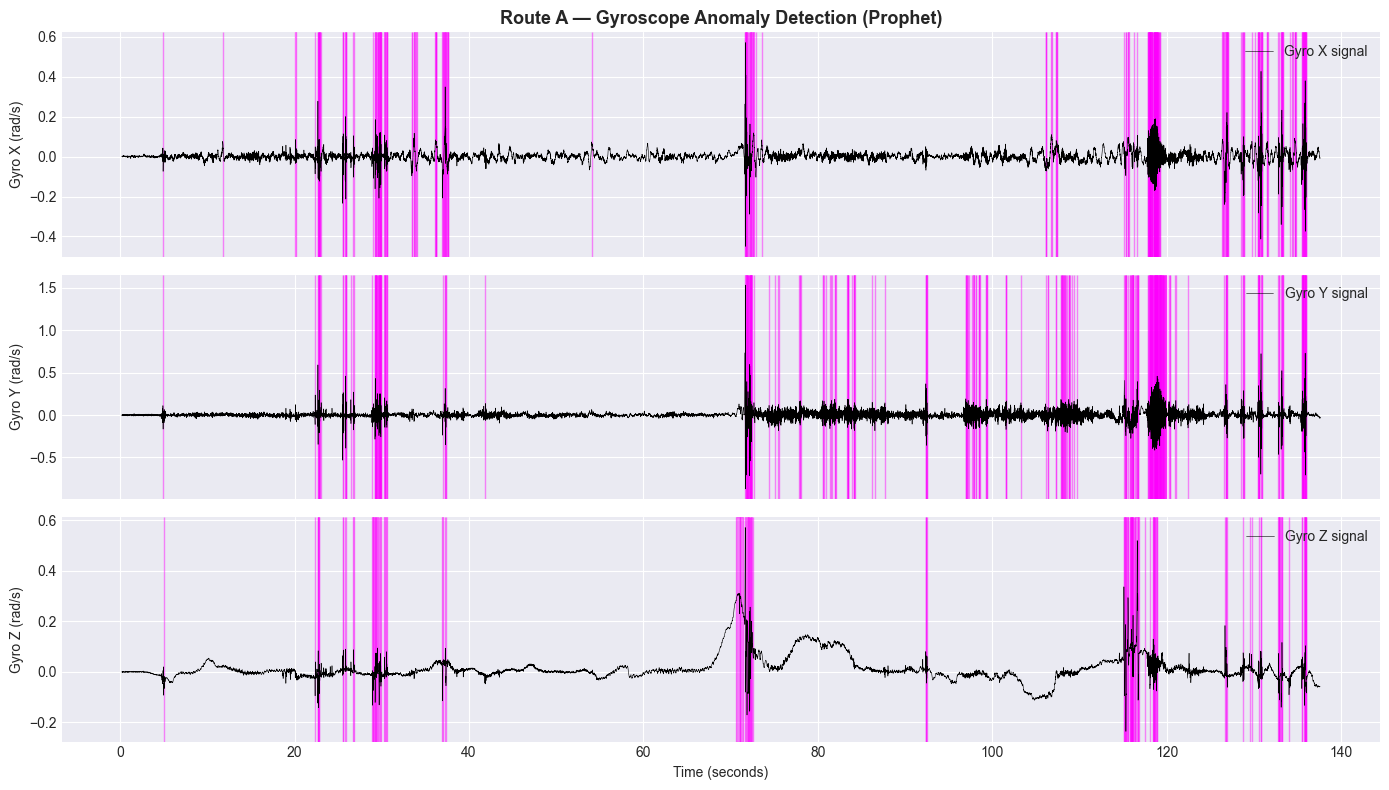

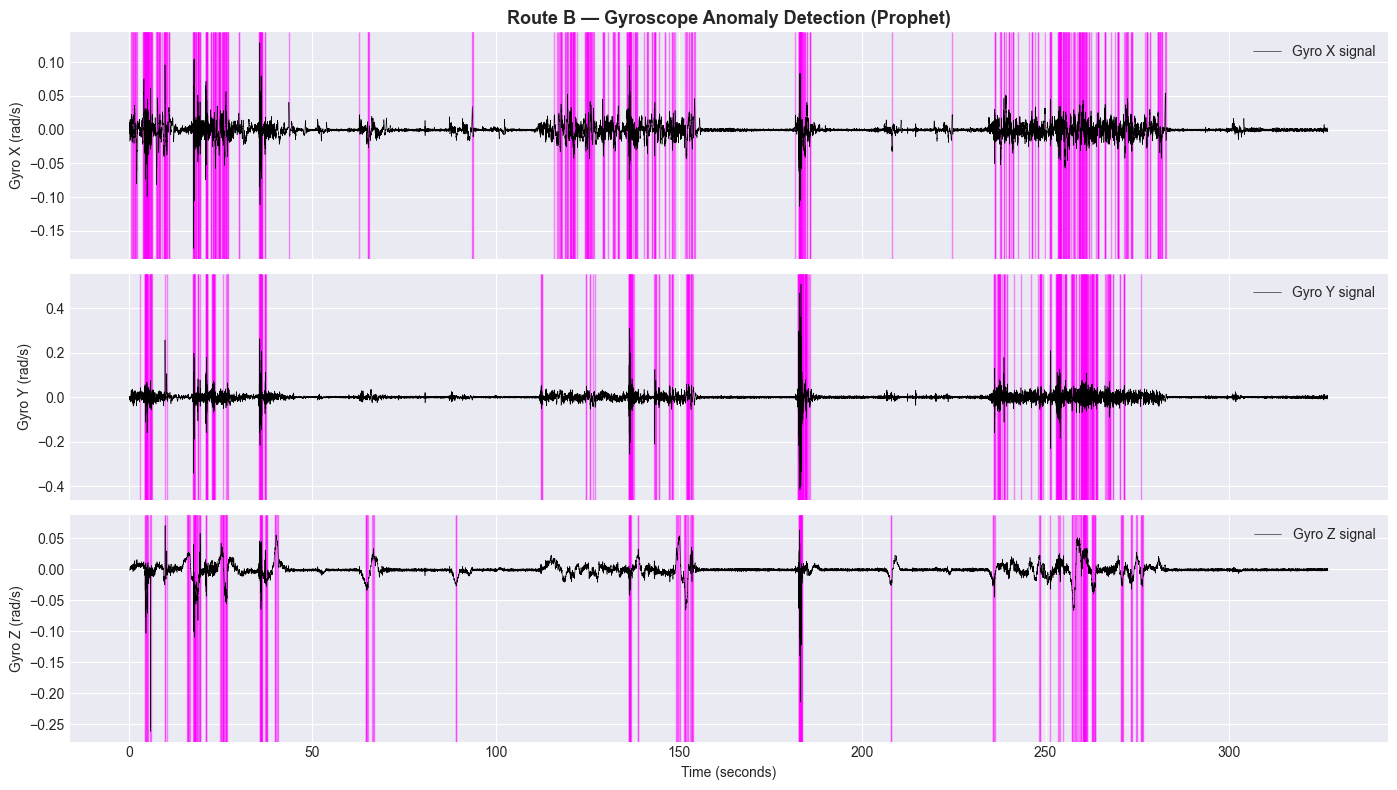

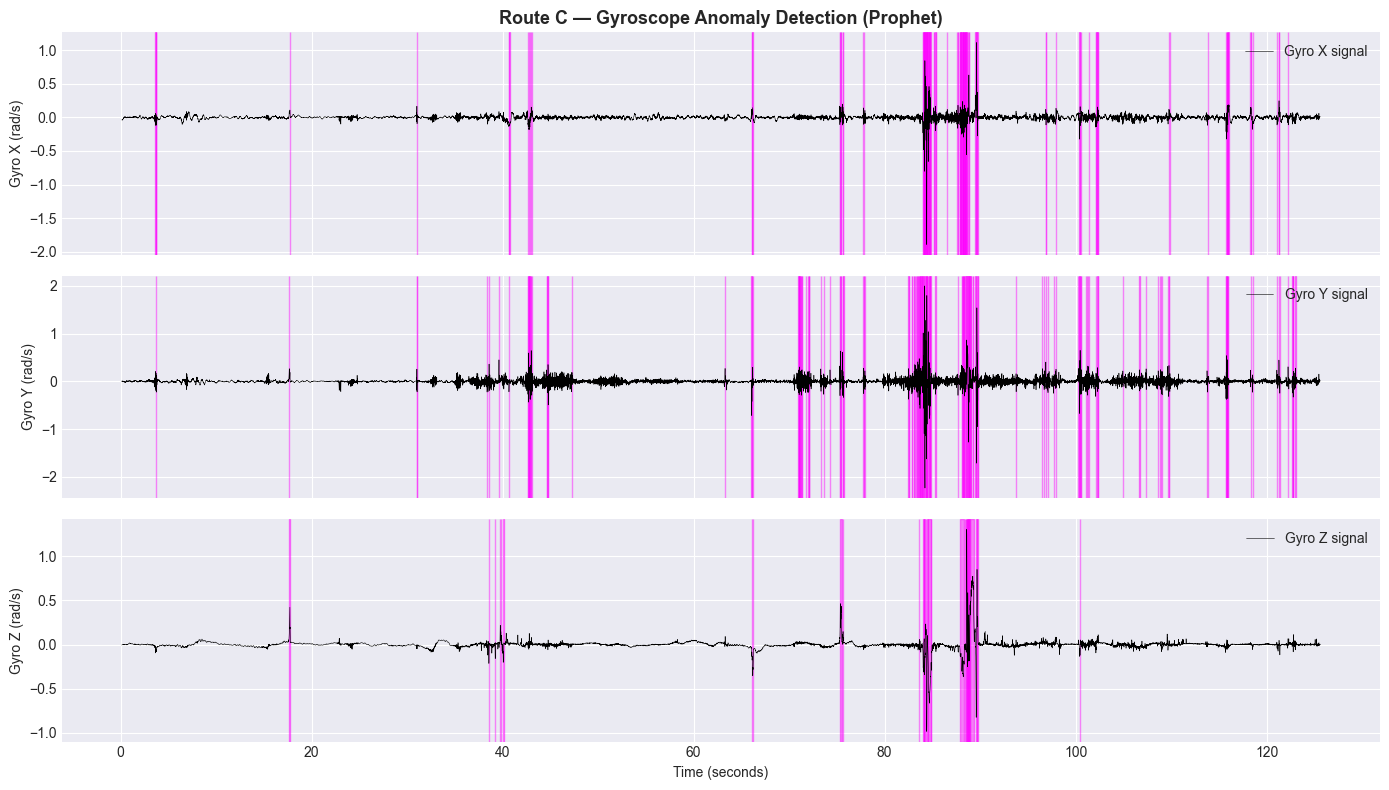

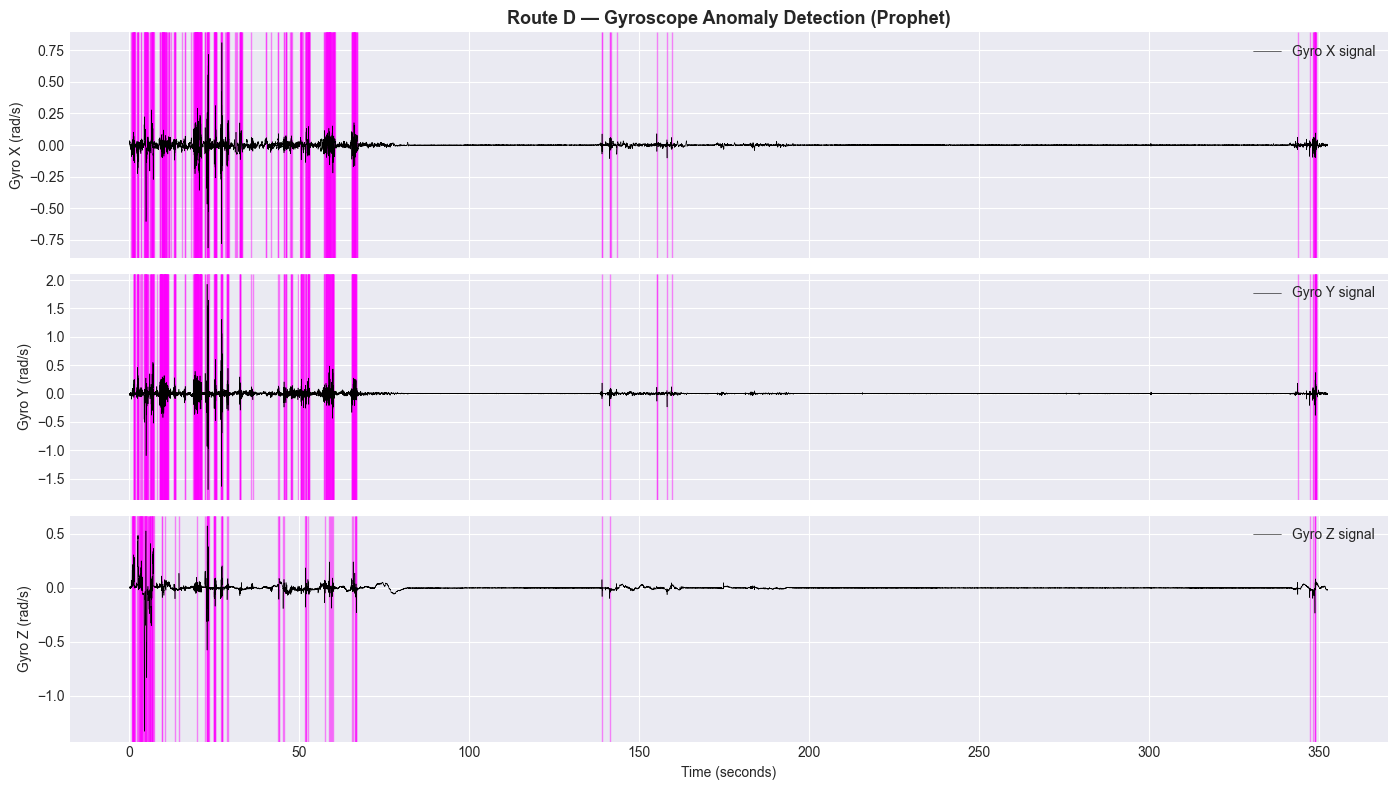

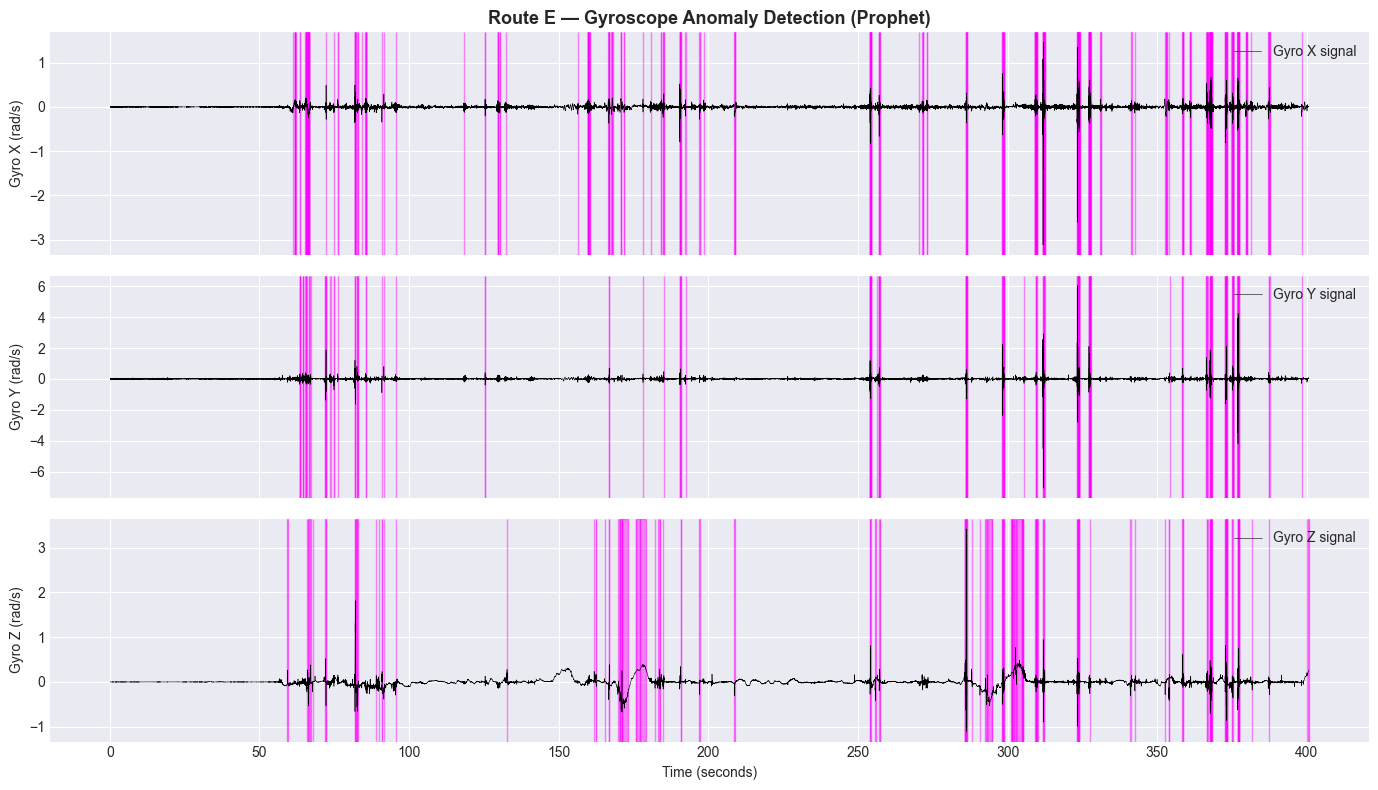

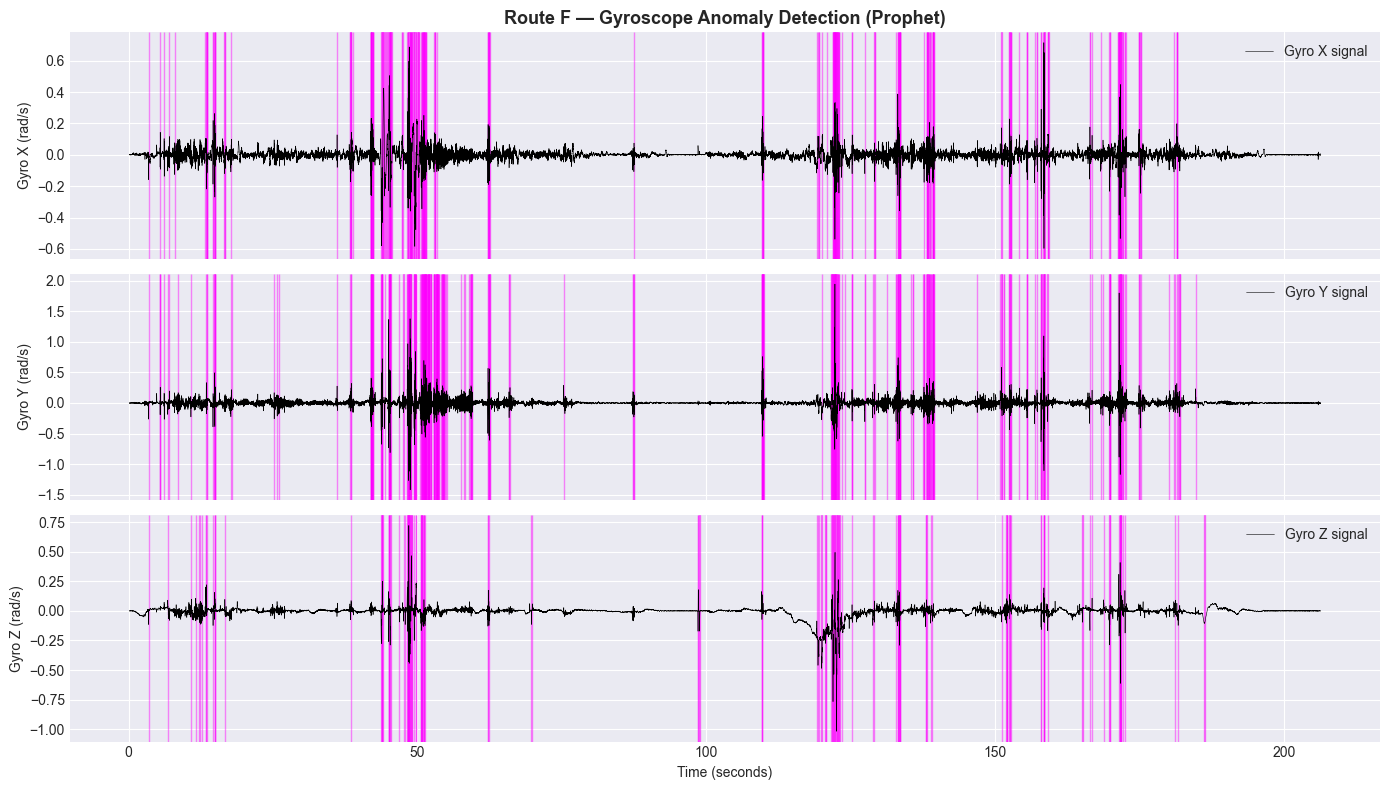

In [26]:
def get_seg_list(seconds, anom):
    """Simple (start, end) tuples for shading."""
    segs = []
    in_s = False
    for t, a in zip(seconds, anom):
        if a and not in_s: in_s, st = True, t
        elif not a and in_s: in_s = False; segs.append((st, t))
    if in_s: segs.append((st, float(seconds.iloc[-1])))
    return segs

for folder in folders:
    g = all_data[folder]['gyro']
    r = results[folder]
    t = g['seconds_elapsed']

    fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for i, (axis, label) in enumerate([('x','Gyro X'), ('y','Gyro Y'), ('z','Gyro Z')]):
        axs[i].plot(t, g[axis], color='black', lw=0.4, label=f'{label} signal')
        for s in get_seg_list(t, r[f'anom_{axis}']):
            axs[i].axvspan(s[0], s[1], color='magenta', alpha=0.45)
        axs[i].set_ylabel(f'{label} (rad/s)')
        axs[i].legend(loc='upper right')

    axs[0].set_title(f'Route {folder} — Gyroscope Anomaly Detection (Prophet)',
                      fontsize=13, fontweight='bold')
    axs[2].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.savefig(f'gyro_anomaly_{folder}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 8. Driver Behavior Plot (Acceleration / Deceleration per route)

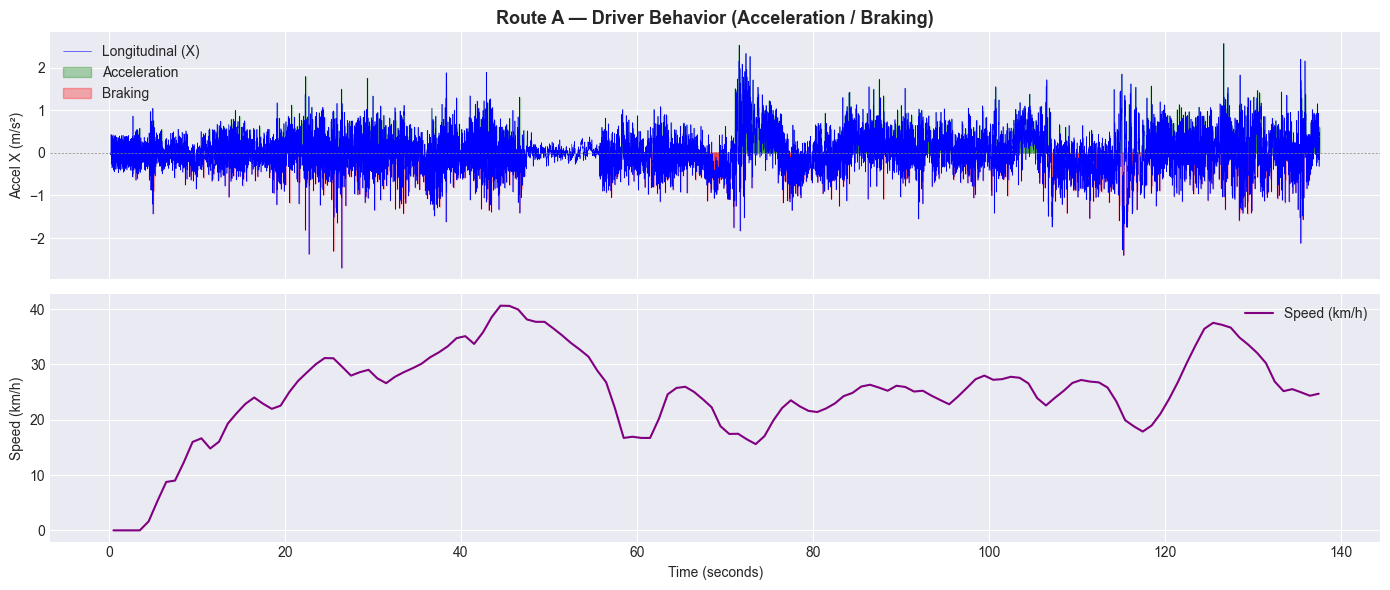

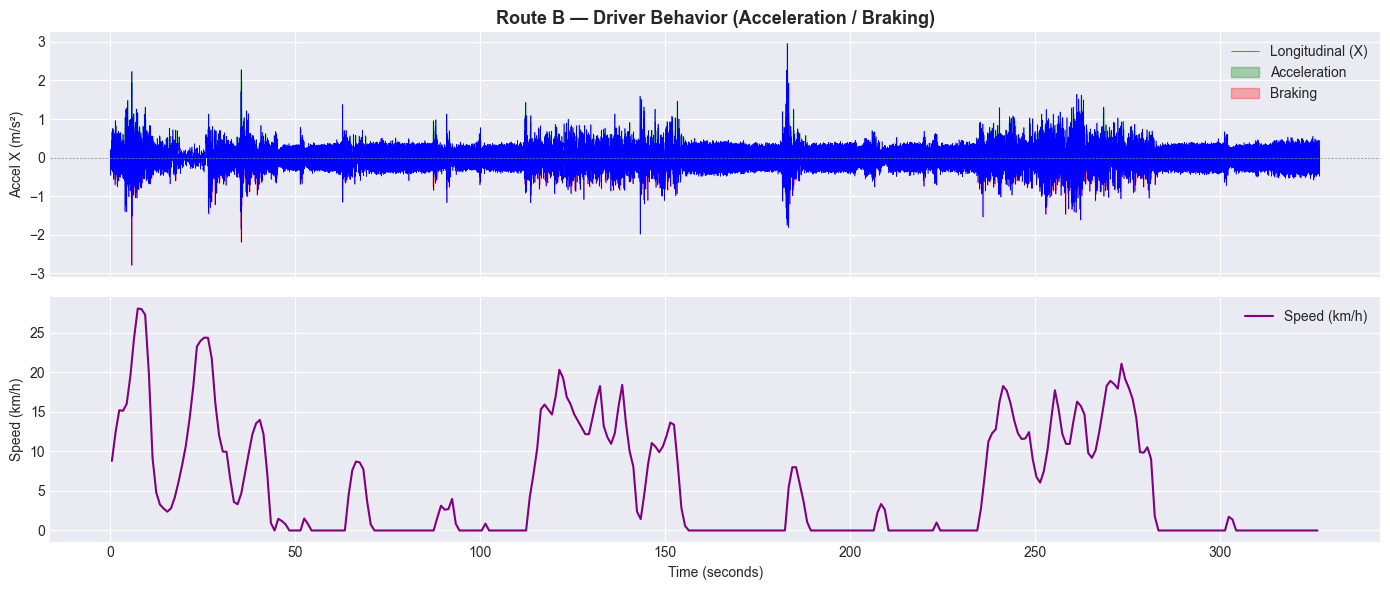

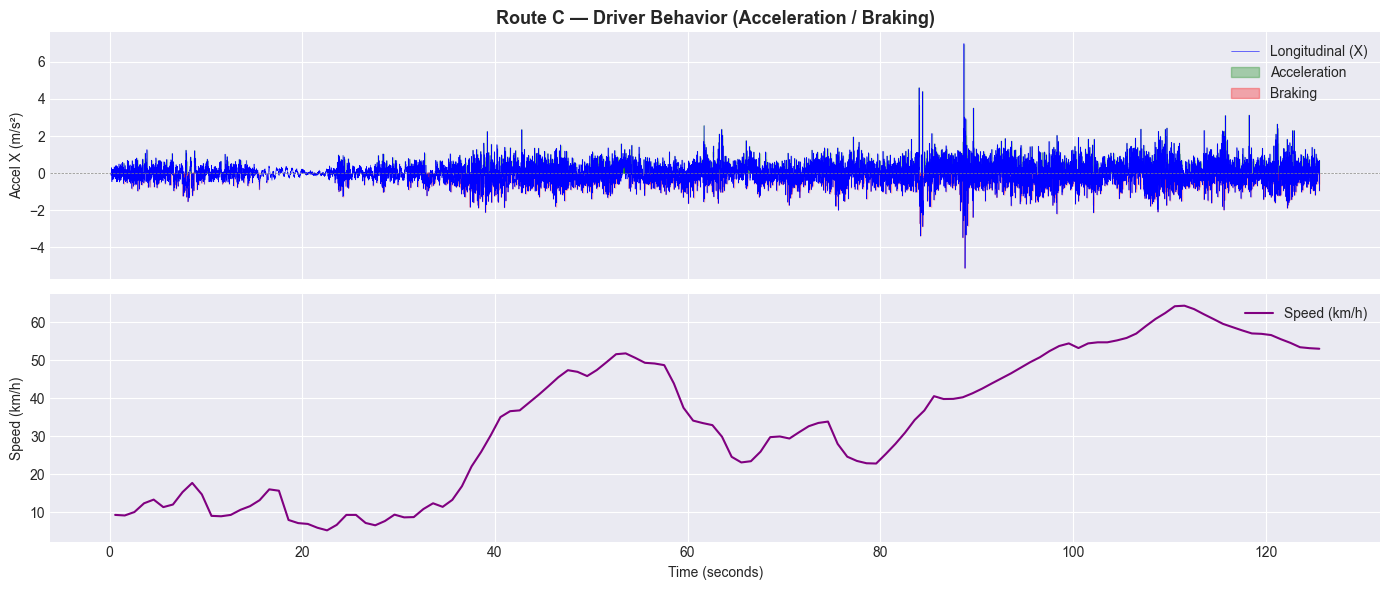

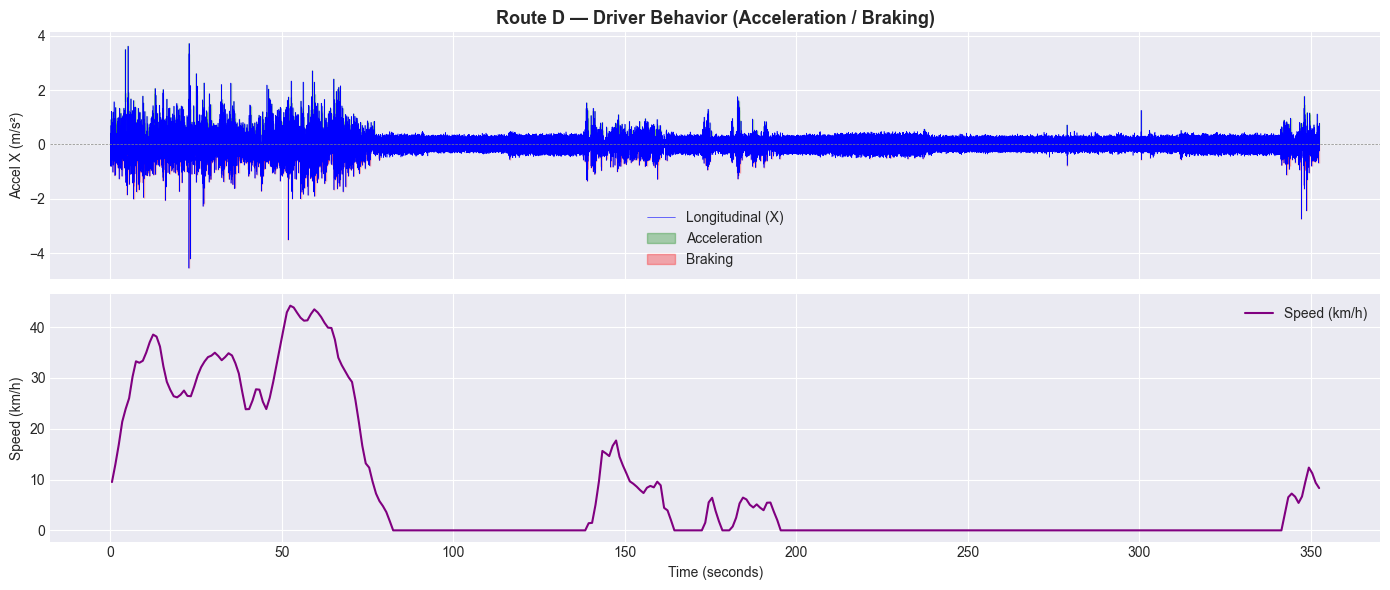

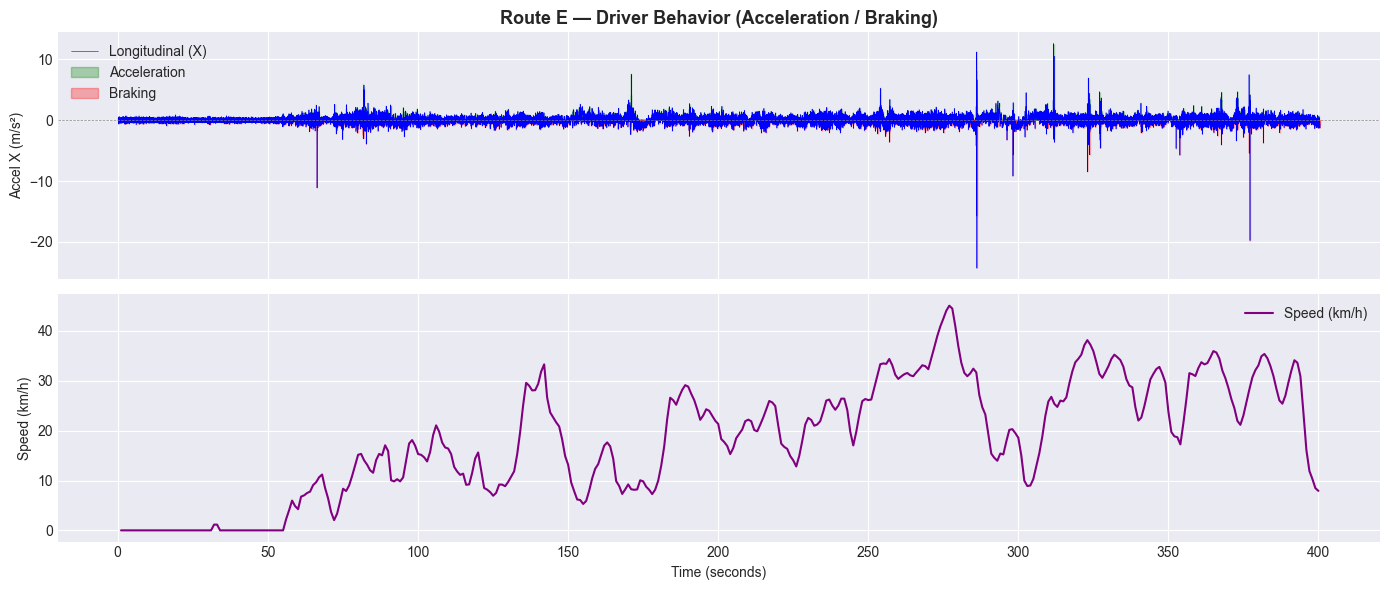

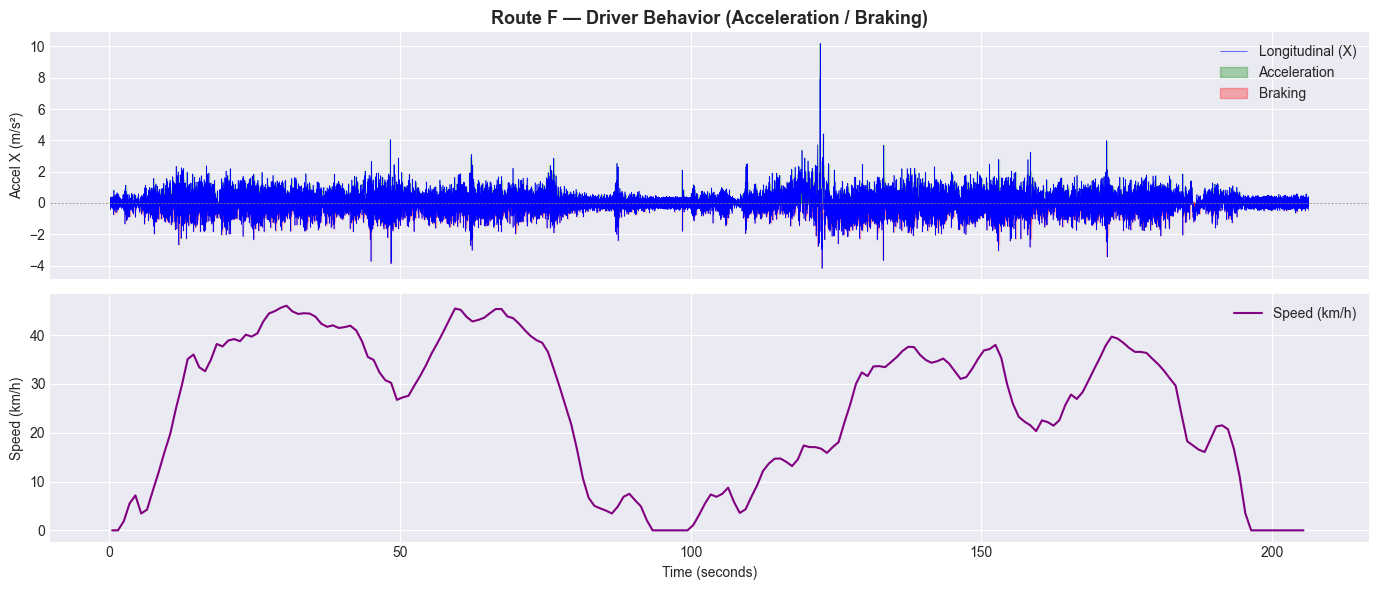

In [27]:
for folder in folders:
    accel = all_data[folder]['accel']
    loc   = all_data[folder]['location']
    t     = accel['seconds_elapsed']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # Longitudinal acceleration (x-axis = forward/back) → driver behavior
    ax1.plot(t, accel['x'], color='blue', lw=0.4, label='Longitudinal (X)')
    ax1.axhline(0, color='gray', ls='--', lw=0.5)
    ax1.fill_between(t, accel['x'], 0, where=accel['x'] > 0.5,
                     color='green', alpha=0.3, label='Acceleration')
    ax1.fill_between(t, accel['x'], 0, where=accel['x'] < -0.5,
                     color='red', alpha=0.3, label='Braking')
    ax1.set_ylabel('Accel X (m/s²)')
    ax1.set_title(f'Route {folder} — Driver Behavior (Acceleration / Braking)',
                   fontsize=13, fontweight='bold')
    ax1.legend()

    # Speed from GPS
    ax2.plot(loc['seconds_elapsed'], loc['speed'] * 3.6,  # m/s → km/h
             color='purple', lw=1.5, label='Speed (km/h)')
    ax2.set_ylabel('Speed (km/h)')
    ax2.set_xlabel('Time (seconds)')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'driver_behavior_{folder}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 9. Road Roughness Profile Plot

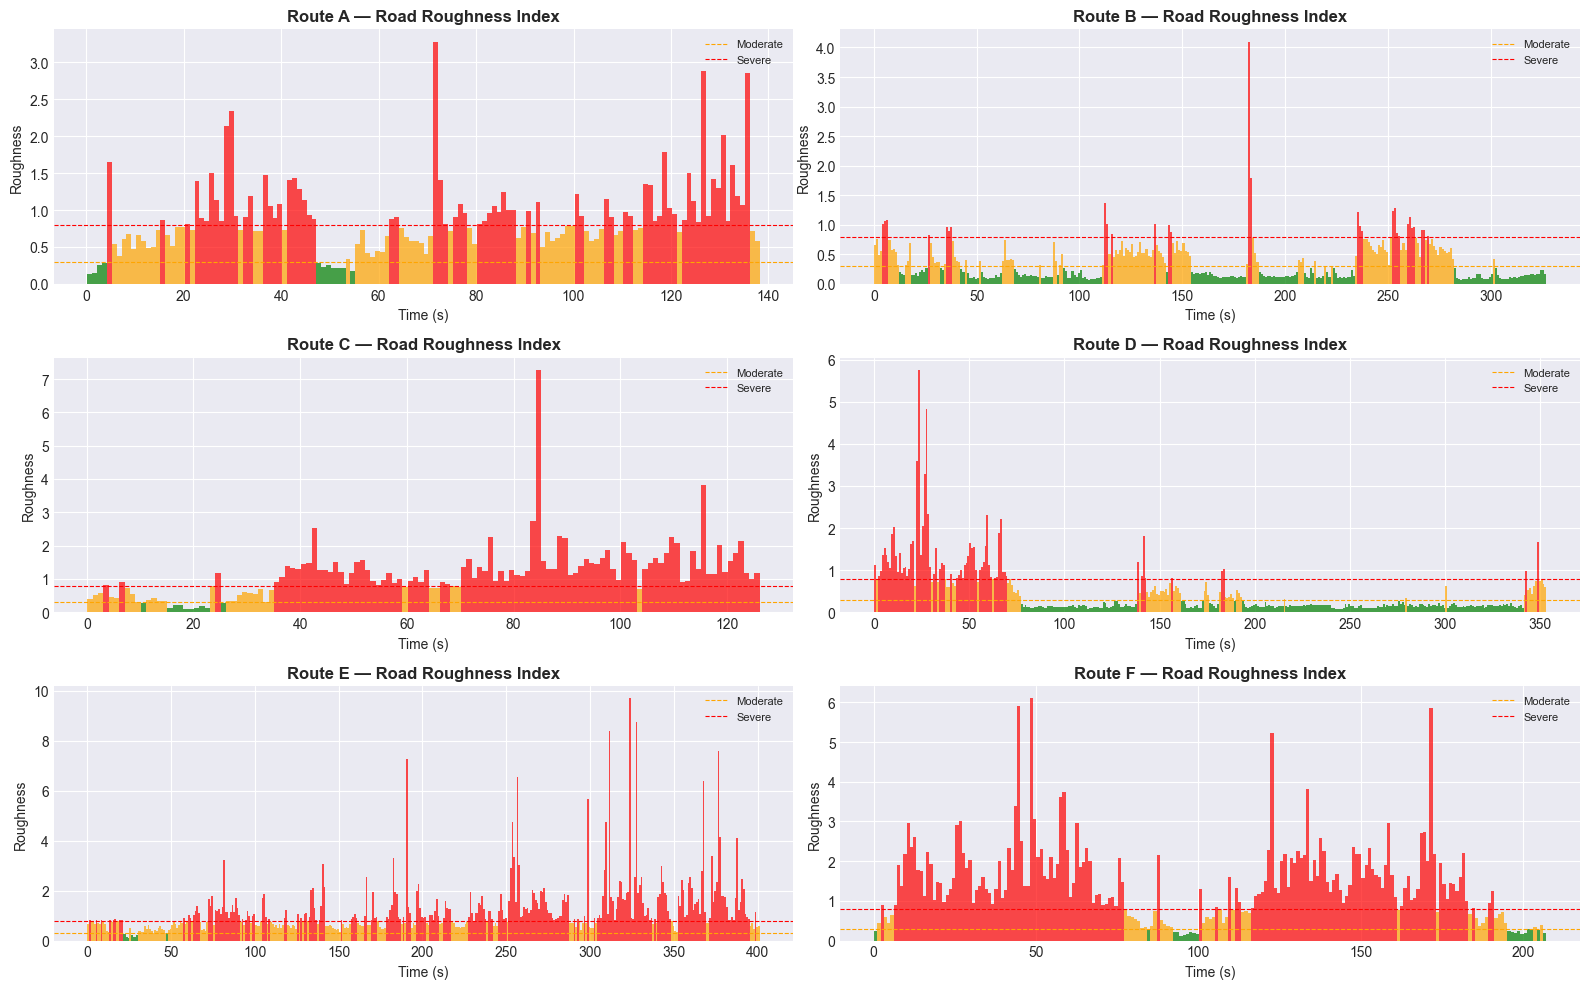

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()
for i, folder in enumerate(folders):
    r = roughness_data[folder]
    ax = axes[i]
    colors = ['green' if v < 0.3 else 'orange' if v < 0.8 else 'red'
              for v in r['roughness']]
    ax.bar(r['sec'], r['roughness'], width=1.0, color=colors, alpha=0.7)
    ax.set_title(f'Route {folder} — Road Roughness Index', fontweight='bold')
    ax.set_ylabel('Roughness')
    ax.set_xlabel('Time (s)')
    ax.axhline(0.3, color='orange', ls='--', lw=0.8, label='Moderate')
    ax.axhline(0.8, color='red', ls='--', lw=0.8, label='Severe')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('road_roughness_all.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Summary & Export

In [29]:
if len(all_clustered) > 0:
    print('='*70)
    print('ROAD ANALYSIS SUMMARY (After clustering + smart filter)')
    print('='*70)

    for folder in folders:
        df = clustered[folder]
        if len(df) == 0:
            print(f"\nRoute {folder}: No events detected.")
            continue
        print(f"\nRoute {folder}: {len(df)} events")
        print(f"  Distribution: {dict(df['event_type'].value_counts())}")
        potholes = df[df['event_type'] == 'Pothole']
        if len(potholes) > 0:
            print(f"  Potholes: {len(potholes)} | "
                  f"Max severity: {potholes['severity'].max():.2f} | "
                  f"Avg confidence: {potholes['confidence'].mean():.2f}")
            print(f"  Largest est. size: {potholes['est_size_m'].max():.2f} m")
        brakes = df[df['event_type'].isin(['Hard Braking', 'Acceleration/Deceleration'])]
        if len(brakes) > 0:
            print(f"  Driver behavior events: {len(brakes)} (filtered from potholes)")
        r_idx = roughness_data[folder]['roughness'].mean()
        print(f"  Avg Road Roughness: {r_idx:.3f} "
              f"({'Good' if r_idx < 0.3 else 'Moderate' if r_idx < 0.8 else 'Poor'})")

    print(f"\n{'='*70}")
    print(f"Total across all routes: {len(all_clustered)} events")
    print(all_clustered['event_type'].value_counts().to_string())

    # Export
    all_clustered.to_csv('road_events_all_routes.csv', index=False)
    print("\nExported → road_events_all_routes.csv")
    display(all_clustered.head(15))
else:
    print('No events detected.')

ROAD ANALYSIS SUMMARY (After clustering + smart filter)

Route A: 8 events
  Distribution: {'Minor Anomaly': np.int64(8)}
  Avg Road Roughness: 0.890 (Poor)

Route B: 2 events
  Distribution: {'Minor Anomaly': np.int64(2)}
  Avg Road Roughness: 0.369 (Moderate)

Route C: 16 events
  Distribution: {'Minor Anomaly': np.int64(8), 'Pothole': np.int64(7), 'Road Bump': np.int64(1)}
  Potholes: 7 | Max severity: 10.00 | Avg confidence: 0.78
  Largest est. size: 5.31 m
  Avg Road Roughness: 1.156 (Poor)

Route D: 6 events
  Distribution: {'Minor Anomaly': np.int64(6)}
  Avg Road Roughness: 0.464 (Moderate)

Route E: 17 events
  Distribution: {'Pothole': np.int64(11), 'Minor Anomaly': np.int64(5), 'Road Bump': np.int64(1)}
  Potholes: 11 | Max severity: 10.00 | Avg confidence: 0.89
  Largest est. size: 5.26 m
  Avg Road Roughness: 1.225 (Poor)

Route F: 13 events
  Distribution: {'Pothole': np.int64(8), 'Minor Anomaly': np.int64(3), 'Hard Braking': np.int64(1), 'Road Bump': np.int64(1)}
  Potho

,latitude,longitude,event_type,severity,avg_severity,confidence,n_detections,total_duration,max_gyro_peak,max_accel_z,max_accel_x,max_dip,max_bump,is_dip,accel_z_std,avg_speed,est_size_m,route
0,30.648925,76.739470,Minor Anomaly,1.272561,1.272561,0.20,1,0.031071,0.079422,1.193139,0.549051,1.193139,0.507180,True,0.757065,4.200290,0.130506,A
1,30.649546,76.740607,Minor Anomaly,10.000000,4.114206,0.95,55,1.522461,0.653823,9.445701,2.709338,9.445701,9.281492,True,1.937165,8.166978,1.195393,A
2,30.650004,76.741467,Minor Anomaly,2.453716,2.453716,0.20,1,0.010357,0.142554,2.311162,0.937285,2.311162,1.203300,True,2.485100,9.576557,0.099183,A
3,30.650718,76.742596,Minor Anomaly,0.256873,0.256873,0.20,1,0.010357,0.092865,0.321091,0.256264,0.000000,0.321091,False,0.080547,8.873394,0.091901,A
4,30.651615,76.743374,Minor Anomaly,10.000000,2.492782,0.95,42,1.947144,1.661362,14.794174,2.528465,9.702309,14.794174,True,1.174474,5.765997,1.956284,A
5,30.652772,76.742272,Minor Anomaly,8.045599,1.383755,0.65,58,0.869972,0.378151,5.248724,1.492570,4.090547,5.248724,True,0.860082,7.028354,1.125473,A
6,30.653559,76.741752,Minor Anomaly,9.166554,2.615189,0.85,79,2.589279,0.537514,5.362134,2.408779,4.437438,5.362134,True,1.352437,5.614248,2.153980,A
7,30.654272,76.740875,Minor Anomaly,10.000000,4.153768,0.85,43,1.812401,0.844094,10.758879,2.567072,10.758879,8.898689,True,2.258074,8.155438,2.770193,A
8,30.659633,76.736522,Minor Anomaly,5.439382,1.045175,0.70,213,10.015547,0.325569,2.795458,2.790935,2.795458,2.212765,True,0.562691,4.831579,3.634738,B
9,30.661657,76.735119,Minor Anomaly,6.253314,1.375664,0.65,197,8.576065,0.191628,3.905081,1.642133,3.391213,3.905081,True,1.003925,3.915923,3.824385,B


## 11. Interactive Leaflet Map
**Color legend:**
- 🔴 Red = Pothole (z went DOWN — wheel dropped into hole)
- 🟢 Green = Road Bump (z went UP — not a pothole!)
- 🟡 Yellow = Speed Breaker  
- 🔵 Blue = Acceleration / Deceleration
- 🟠 Orange = Hard Braking
- ⚪ Gray = Minor Anomaly

**Route paths:** A=red, B=blue, C=green, D=orange, E=purple, F=darkred

In [30]:
if len(all_clustered) == 0:
    print('Nothing to map.')
else:
    EVENT_COLORS = {
        'Pothole': 'red',
        'Road Bump': '#22AA22',              # green — NOT a pothole
        'Speed Breaker': '#FFD700',
        'Acceleration/Deceleration': '#4488CC',
        'Hard Braking': 'orange',
        'Minor Anomaly': '#AAAAAA',
    }
    EVENT_OPACITY = {
        'Pothole': 0.9,
        'Road Bump': 0.5,
        'Speed Breaker': 0.7,
        'Hard Braking': 0.3,
        'Acceleration/Deceleration': 0.25,
        'Minor Anomaly': 0.15,
    }
    ROUTE_COLORS = {'A':'red','B':'blue','C':'green','D':'orange','E':'purple','F':'darkred'}

    centre = [all_clustered['latitude'].mean(), all_clustered['longitude'].mean()]
    m = folium.Map(location=centre, zoom_start=14, tiles='OpenStreetMap')

    # ── Route paths ────────────────────────────────────────────
    for folder in folders:
        loc = all_data[folder]['location']
        coords = list(zip(loc['latitude'], loc['longitude']))
        folium.PolyLine(coords, color=ROUTE_COLORS[folder], weight=4,
                        opacity=0.6, tooltip=f'Route {folder}').add_to(m)

    # ── Event markers ──────────────────────────────────────────
    for _, row in all_clustered.iterrows():
        etype = row['event_type']
        color = EVENT_COLORS.get(etype, 'gray')
        opacity = EVENT_OPACITY.get(etype, 0.2)
        sev = row['severity']
        conf = row['confidence']

        # Size by importance: potholes big, bumps/behavior small
        if etype == 'Pothole':
            radius = max(8, min(20, sev * 2.2))
        elif etype in ('Speed Breaker', 'Road Bump'):
            radius = max(5, min(12, sev * 1.3))
        else:
            radius = 3

        # Direction indicator in popup
        direction = "⬇ DIP (pothole-like)" if row.get('is_dip', False) else "⬆ BUMP (uplift)"

        popup = (f"<b>{etype}</b> (Route {row['route']})<br>"
                 f"Severity: {sev:.1f}/10<br>"
                 f"Confidence: {conf:.0%}<br>"
                 f"Z-direction: {direction}<br>"
                 f"Dip depth: {row.get('max_dip', 0):.2f} m/s²<br>"
                 f"Bump height: {row.get('max_bump', 0):.2f} m/s²<br>"
                 f"Detections merged: {int(row['n_detections'])}<br>"
                 f"Max gyro: {row['max_gyro_peak']:.3f} rad/s<br>"
                 f"Est. size: {row['est_size_m']:.2f} m<br>"
                 f"Speed: {row['avg_speed']:.1f} m/s ({row['avg_speed']*3.6:.0f} km/h)<br>"
                 f"<a href='https://www.google.com/maps?q={row['latitude']},{row['longitude']}' "
                 f"target='_blank'>Google Maps</a>")

        folium.CircleMarker(
            [row['latitude'], row['longitude']],
            radius=radius, color=color, fill=True,
            fill_color=color, fill_opacity=opacity,
            popup=folium.Popup(popup, max_width=300),
            tooltip=f"{etype} | sev={sev:.1f} | conf={conf:.0%}"
        ).add_to(m)

    # ── Legend ──────────────────────────────────────────────────
    legend_html = '''
    <div style="position:fixed; bottom:30px; left:30px; z-index:9999;
                background:white; padding:12px; border:2px solid gray;
                border-radius:8px; font-size:13px; opacity:0.92;">
    <b>Road Surface Events</b><br>
    <span style="color:red">&#11044;</span> Pothole (z ⬇ dip)<br>
    <span style="color:#22AA22">&#11044;</span> Road Bump (z ⬆ uplift)<br>
    <span style="color:#FFD700">&#11044;</span> Speed Breaker<br>
    <br><b>Driver Behavior (dimmed)</b><br>
    <span style="color:#4488CC">&#11044;</span> Accel/Decel<br>
    <span style="color:orange">&#11044;</span> Hard Braking<br>
    <span style="color:#AAAAAA">&#11044;</span> Minor Anomaly<br>
    <br><b>Routes</b><br>
    <span style="color:red">&#9473;</span> A &nbsp;
    <span style="color:blue">&#9473;</span> B &nbsp;
    <span style="color:green">&#9473;</span> C<br>
    <span style="color:orange">&#9473;</span> D &nbsp;
    <span style="color:purple">&#9473;</span> E &nbsp;
    <span style="color:darkred">&#9473;</span> F
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    folium.LayerControl().add_to(m)
    m.save('road_analysis_map.html')
    print('Saved → road_analysis_map.html')
    m

Saved → road_analysis_map.html


In [32]:
# === INVESTIGATE Route A & C briefly ===
a_ev = all_events['A']
print(f"Route A: {len(a_ev)} events → {a_ev['event_type'].value_counts().to_dict()}")
ph = a_ev[a_ev['event_type']=='Pothole']
print(f"Potholes: {len(ph)}")
if len(ph) > 0:
    print(ph[['latitude','longitude','severity','dip_magnitude','gyro_peak']].head(10).to_string())

print()
c_ev = all_events['C']
print(f"Route C: {len(c_ev)} events → {c_ev['event_type'].value_counts().to_dict()}")
c_ph = c_ev[c_ev['event_type']=='Pothole']
print(f"Potholes: {len(c_ph)}")
if len(c_ph) > 0:
    print(c_ph[['latitude','longitude','severity','dip_magnitude','gyro_peak']].head(10).to_string())

# Raw Z-accel stats  
for r in ['A','C']:
    t = all_data[r]['total']
    print(f"\nRoute {r} TotalAccel Z: mean={t['z'].mean():.2f} std={t['z'].std():.2f} min={t['z'].min():.2f} max={t['z'].max():.2f}")

Route A: 280 events → {'Minor Anomaly': 150, 'Pothole': 63, 'Road Bump': 55, 'Hard Braking': 10, 'Speed Breaker': 2}
Potholes: 63
     latitude  longitude   severity  dip_magnitude  gyro_peak
2   30.649269  76.740056   6.595912       3.255416   0.248673
3   30.649269  76.740056   7.120702       2.720091   0.653823
6   30.649269  76.740056   4.213010       1.826263   0.312518
9   30.649382  76.740282   6.462440       2.380121   0.581895
11  30.649382  76.740282   8.152034       3.675848   0.510390
12  30.649382  76.740282   4.876964       2.524997   0.140806
13  30.649382  76.740282   6.410281       3.799274   0.179638
15  30.649420  76.740353   4.869769       2.318678   0.304259
16  30.649493  76.740493  10.000000       9.445701   0.144996
17  30.649529  76.740565   6.304921       3.473294   0.147304

Route C: 159 events → {'Minor Anomaly': 67, 'Pothole': 65, 'Road Bump': 23, 'Hard Braking': 3, 'Acceleration/Deceleration': 1}
Potholes: 65
     latitude  longitude   severity  dip_magnit